In [25]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [26]:
s1_interferogram = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    polarization="VV",
    sub_swath="IW1",
    spatial_extent={
        "west": 13.10,
        "south": 42.60,
        "east": 13.38,
        "north": 42.78
    },
    temporal_baseline=6,
    temporal_extent = ["2018-08-01", "2018-08-24"]
)

# s1_interferogram.execute_batch(title="please run")

In [27]:
phase_to_displacement_udf =openeo.UDF.from_file("displacement_udf.py")

In [32]:
s1_displacement = s1_interferogram.apply_dimension(
    process=phase_to_displacement_udf,
    dimension="bands"
)

In [33]:
s1_displacement.execute_batch(title="udf v1")

Preflight process graph validation raised: [ProcessParameterInvalid] The value passed for parameter 'data' in process 'apply_dimension' is invalid: Expected raster cube or vector cube but got <class 'openeogeotrellis.stac_save_result.StacSaveResult'>.


0:00:00 Job 'j-26080513080147108f05b79aa2f6f112': send 'start'


OpenEoApiError: [400] ProcessParameterInvalid: The value passed for parameter 'data' in process 'apply_dimension' is invalid: Expected raster cube or vector cube but got <class 'openeogeotrellis.stac_save_result.StacSaveResult'>. (ref: r-260805130802477d9962e6c27aaa5169)

# applying outside udf

In [36]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [38]:
job = connection.job("j-2608050918524fae9f64458018ebb235")
# results = job.get_results()
# results.download_files("interferogram/")

In [1]:
import rasterio

image1 = rasterio.open("interferogram/phase_coh_20180806T165709_20180812T165751.tif")

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_28084\2423649452.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  plt.imshow(image1.read(1), cmap='gray')


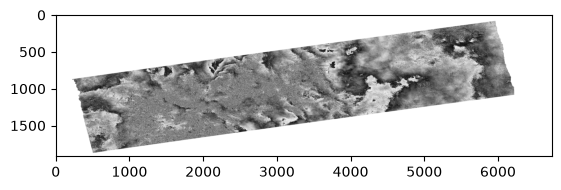

In [2]:
import matplotlib.pyplot as plt

plt.imshow(image1.read(1), cmap='gray')


In [56]:
import numpy as np
# check if it has all nans or not
all_nans = np.isnan(displacement).all()
all_nans

np.False_

In [46]:
coh = image1.read(2)
phase = image1.read(1)

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_12000\2342776055.py:1: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh = image1.read(2)
C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_12000\2342776055.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  phase = image1.read(1)


In [47]:
LAMBDA_M = 0.05546          # Sentinel-1 C-band wavelength [m]
COHERENCE_THRESHOLD = 0.30  # mask pixels below this coherence
GRADIENT_PERCENTILE = 98    # flag steepest local-phase-gradient pixels as artifacts

In [59]:
import numpy as np
# convert phase to displacement
displacement = -phase * LAMBDA_M / (4 * np.pi)
# check if it has all nans or not
print("All NaNs in displacement:", np.isnan(displacement).all())

All NaNs in displacement: False


In [61]:
# 2) coherence mask - discard unreliable / decorrelated pixels
filtered_displacement = np.where(coh < COHERENCE_THRESHOLD, np.nan, displacement)
print("All NaNs in displacement after coherence mask:", np.isnan(displacement).all())

All NaNs in displacement after coherence mask: False


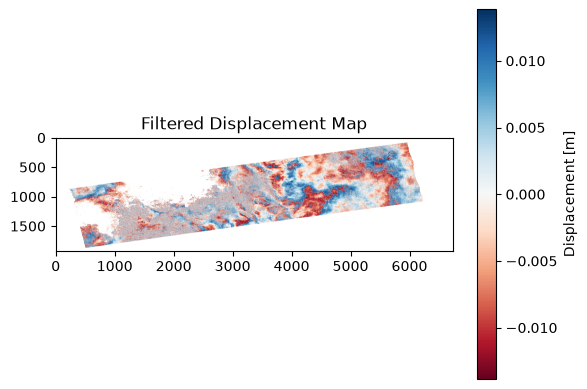

In [63]:
# plot the filtered displacement
import matplotlib.pyplot as plt
plt.imshow(filtered_displacement, cmap="RdBu")
plt.colorbar(label="Displacement [m]")
plt.title("Filtered Displacement Map")
plt.show()

In [45]:
phase_to_displacement_udf = """
import numpy as np
import xarray as xr

LAMBDA_M = 0.05546          # Sentinel-1 C-band wavelength [m]
COHERENCE_THRESHOLD = 0.30  # mask pixels below this coherence
GRADIENT_PERCENTILE = 98    # flag steepest local-phase-gradient pixels as artifacts


def apply_datacube(cube: xr.DataArray, context: dict) -> xr.DataArray:
    coherence = cube.sel(bands="coherence")
    phase = cube.sel(bands="phase_unwrapped")

    # 1) convert phase to LOS displacement
    displacement = -(LAMBDA_M / (4 * np.pi)) * phase

    # 2) coherence mask - discard unreliable / decorrelated pixels
    displacement = displacement.where(coherence >= COHERENCE_THRESHOLD)

    # 3) artifact flag - large local phase gradients usually indicate a residual
    #    fringe or a local unwrapping error rather than real ground motion
    dy = phase.differentiate("y")
    dx = phase.differentiate("x")
    gradient_mag = np.sqrt(dx ** 2 + dy ** 2)
    gradient_cutoff = gradient_mag.quantile(GRADIENT_PERCENTILE / 100.0)
    displacement = displacement.where(gradient_mag < gradient_cutoff)

    result = xr.concat([displacement, coherence], dim="bands")
    result = result.assign_coords(bands=["los_displacement_m", "coherence"])
    return result
"""
